# Where the coupled fit starts: every supported initializer at one budget

Thirteen starts of the coupled spatio-sequential model's emission parameters
(issues #887, #891), each run from its own seam at one budget, once per seed
of `TRIALS` --- one seed for now, see below --- and read against the value the
generating parameters reach on the same draw.

Three terms the rest uses:

- A **`Budget`** (`opt.budget.Budget`) is a ceiling on the unit a method
  spends, held equal across methods so their results compare. Every fit here
  spends at most six **passes** over the data, a pass being every observation
  scored under every component.
- A **nat** is the unit of a log-likelihood difference in natural logarithms:
  a gap of `Δ = 1` nat is a likelihood ratio of `e ≈ 2.718`.
- After its start, every fit runs the same loop: the expectation-maximization
  iterations `search.projection.fit_projection` runs, one E step and one M
  step per pass, so what separates two rows is the start and nothing after it.

The instance is `spatio_sequential_counts/release`: a 10x10 open triangular
lattice of 100 vertices, `M = 10` classes, `K = 10` hidden states per class,
`S = 1,000` positions, two-channel counts. It has no exact evidence, so the
reference every row is read against is the **generating parameters' own
value** on the draw, stated as such; where a regression test pins a number,
the test is named beside it.

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.opt.budget import Budget, compare
from snakes_and_ladders.opt.mixture import (
    mixture_log_likelihood,
    responsibilities,
    seeding_guarantee,
)
from snakes_and_ladders.qa import forney, mixture_seeding
from snakes_and_ladders.qa.style import discrete_palette, notebook_style
from snakes_and_ladders.search.projection import (
    DETERMINISTIC,
    LOCATION_SEEDINGS,
    SEEDINGS,
    CountPairAt,
    TimedFit,
    Trial,
    flatten,
    project,
)
from snakes_and_ladders.sim.count_pairs import TOTAL, binned_model
from snakes_and_ladders.sim.fixtures import fixture

np.set_printoptions(precision=3, suppress=True)

# The seed of every draw outside the trials: the guarantee's seedings and the
# Gaussian control drawn in section (d). The trials take the seeds in TRIALS.
SEED = 891

## The instance

`fixture` reads the declared file; nothing here builds an instance. The QA
renderer `qa.forney` draws the model as a factor graph of this instance: the
label variables on the lattice with their pairwise Potts factors, one Markov
chain per class behind them, and the gated emission factors joining a site's
label, its counts and every chain's state at a position. It draws a 5x5 window
of the lattice, two of the ten chains and the first four positions, and its
caption states the declared sizes.

vertices 100 classes 10 states 10 positions 1000 bin factors (1,)


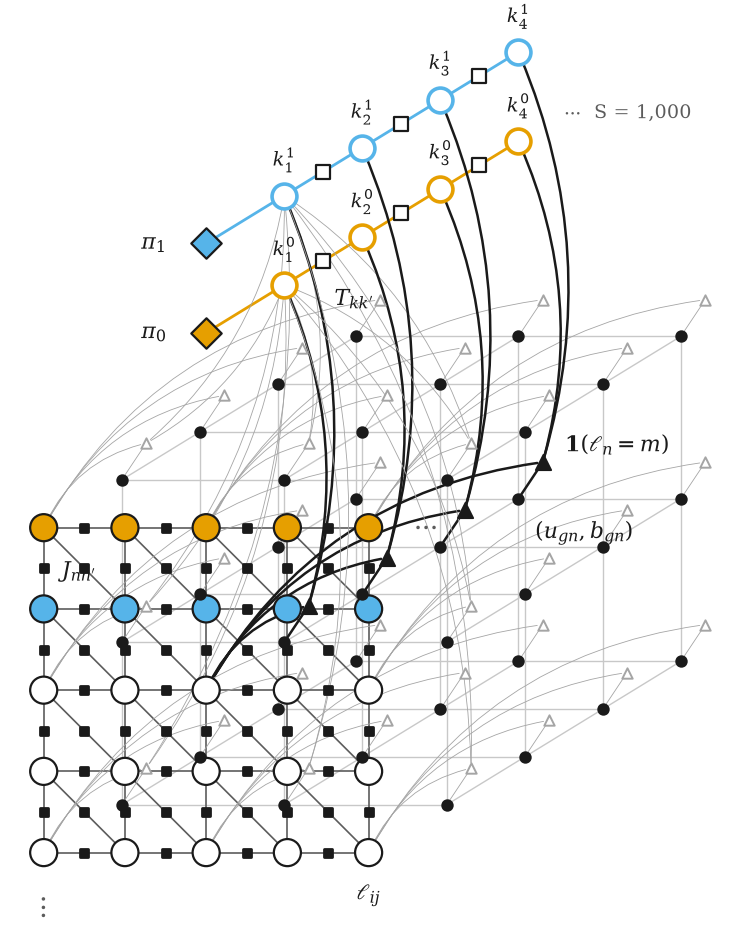

The coupled spatio-sequential model as a factor graph, for the declared instance: 100 label variables on a 10 by 10 lattice, M = 10 classes of K = 10 hidden states, over S = 1000 positions. Drawn: the leading 5 by 5 window of the lattice and the first 4 positions, at most 5 sites per lattice axis and 4 positions. The front face holds a label variable per site, filled by its planted class where that class's chain is drawn and white where it is not, and a Potts factor J as a square on every lattice edge. Behind it, 2 of the 10 chains: the initial-distribution node, a diamond, and a state variable per position, with a transition factor T as a square between consecutive ones. Emission variables, the pair of counts, are dots at every 2-th site on each axis and every drawn position, tied into cuboids by thin edges. The gated emission factor, a triangle, joins a site's label, its emission and the state of every drawn chain at that position; black at one site, and grey at the rest of the subsa

In [2]:
# The declared instance: the file under tests/regression/fixtures/, its seed,
# its bin factors and its model, validated by the count-pair loader.
declared = fixture("spatio_sequential_counts", "release").params
# The declared model at bin factor 1: positions unbinned, so the emissions are
# the declared ladders and not an aggregate of them.
model = binned_model(declared.model, 1)
print(
    "vertices",
    model.graph.n_nodes,
    "classes",
    model.n_classes,
    "states",
    model.n_states,
    "positions",
    model.n_positions,
    "bin factors",
    declared.factors,
)

with notebook_style():
    # The factor graph of this model, drawn from its sizes and its planted
    # labelling; the caption is the renderer's own.
    figure, caption = forney.build_figure(model, emission_stride=2, classes_shown=2)
    plt.show()
print(caption)

## The projection, and the reference the starts are read against

Drop the spatial coupling and the chain from the coupled model and each
observation is one draw from a mixture over the `M x K = 100` (class, state)
pairs, the surface a seeding of the emission parameters sees. That is the
instance experiment 009 compared its candidates on: 100 components over 4,000
observations, 40 a component.

The reference is the log-likelihood the **generating parameters** reach on this
draw. It is not an upper bound: a fit of 4,000 draws may pass it, and a gap
below zero is a fit that passed it.

In [3]:
# The projection: 4,000 draws of the M x K emission mixture the coupled model
# implies, a class drawn by its share of the planted labelling and a state
# uniformly -- the instance experiment 009 fitted.
projected = project(model, 4000, np.random.default_rng([541, 0]))
# The M per-class families as one M x K family, class-major: the truth the
# starts are read against.
truth = flatten(model)
# The seam that places a component on an observed pair, with the pooled
# dispersion and concentration: one observation carries no shape, so every
# start begins its components at these two.
at = CountPairAt(
    float(truth.total.dispersion.mean()),
    float(truth.successes.concentration.mean()),
    projected.trials,
)

# Experiment 009's six passes: a seeding is a claim about where a fit starts,
# so the fit is held short enough that the claim is still visible where it
# ends.
BUDGET = Budget(Cost.PASSES, 6)

values = torch.as_tensor(projected.observations, dtype=torch.float64)
log_weight = torch.log(torch.as_tensor(projected.weights, dtype=torch.float64))
# The mixture log-likelihood at the generating parameters: the reference.
REFERENCE = float(mixture_log_likelihood(values, log_weight, truth))
# The fraction of observations the generating parameters assign to their
# generating component: the recovery the truth itself reaches.
bayes = float(
    np.mean(
        responsibilities(values, log_weight, truth).argmax(dim=1).numpy()
        == projected.components
    )
)
print(
    "components",
    projected.n_components,
    "observations",
    projected.n_samples,
    "budget",
    BUDGET.size,
    BUDGET.unit,
)
print(f"the generating parameters reach {REFERENCE:.1f} nats")
print(f"and assign {bayes:.4f} of observations to their generating component")

components 100 observations 4000 budget 6 passes
the generating parameters reach -35319.1 nats
and assign 0.0542 of observations to their generating component


## Every start, once per seed

Every start ends at the same seam --- it chooses `M x K` locations and
`CountPairAt` places a component on each --- and then runs the same loop at the
same budget. The trials run through `opt.budget.compare`, which hands each
(start, seed) cell to `snakes_and_ladders.parallel` on a pool of four worker
processes, one per core of the host, each cell seeding its own generator
`default_rng([seed, 0])`, so a cell draws the same stream at every worker
count, and each worker runs torch at one intra-op thread. Each cell is
a `search.projection.TimedFit`: the seeding and the fit inside one `track`
block, whose run records the log-likelihood per iteration, the bytes the state
holds and the seconds since the block opened. A start that reads no generator
runs once. The comparison's own budget is a ceiling in `Cost.SECONDS`, which a
cell that ran longer would overspend and be refused on.

**One trial for now, and `TRIALS` is the one constant to raise.** One six-pass
fit at this instance is about 26 s on one core: each pass's M step is 4.6 s of
its 5.0 s, `_solve_beta_binomial` running one bisection per component, 100 of
them (cProfile). Ten trials of every start would take about 700 s on four
workers, over the 600 s a notebook may spend (`DEV.md`). Issue #892 vectorizes
the M step across components; once it lands, `TRIALS` goes to ten, and every
loop, column and range below already reads it.

Each section below prints its starts' rows. A row states, over its trials: the
log-likelihood at the start (seeded value) and at the budget (reached value),
the **gap**, which is the reference less the reached value, the **recovery**,
the fraction of observations the fit assigns to their generating component up
to the best renaming of the components, the **mean relative error**, the
largest relative error left in a component's negative-binomial mean, the
passes the start itself charged, and the bytes of the fit's state. Values are
means over the trials; at more than one trial the gap and the recovery also
carry the **range**, `[min, max]`, and at one they are that trial's value. The
seconds column is in the last section, because a wall clock is
not reproducible text.

In [4]:
#: Seeds of every start that reads a generator: one while a fit costs 26 s,
#: ten once issue #892 brings it under 5 s. The one constant to raise.
TRIALS = [0]

#: Cells run at once, one worker process per core of the 4-core host;
#: `compare` runs each at one intra-op thread.
WORKERS = 4

#: The comparison's ceiling in seconds, per cell: about sixteen times the
#: slowest cell measured, 37 s, so it refuses a fit that ran away and no fit
#: that ran.
CEILING = Budget(Cost.SECONDS, 600)

# Every start, experiment 009's eight and the five that return locations,
# in the order the sections below take them.
STARTS = {**SEEDINGS, **LOCATION_SEEDINGS}
ORDER = [
    "prior",
    "data",
    "kmeans++",
    "emission++",
    "gaussian-em",
    "objective",
    "perturbed",
    "restart",
    "quantile",
    "burn-in",
    "hmc",
    "anneal",
    "tempering",
]
GROUPS = {
    "stochastic": ([n for n in ORDER if n not in DETERMINISTIC], TRIALS),
    "deterministic": ([n for n in ORDER if n in DETERMINISTIC], [0]),
}

load_before = os.getloadavg()
opened = time.perf_counter()
comparisons = {}
trials: dict[str, list[Trial]] = {}
for group, (names, seeds) in GROUPS.items():
    # Every (start, seed) cell of the group on the pool, scored against the
    # reference: its value, its whole seconds, and the Trial it carries back.
    comparison = compare(
        {name: TimedFit(name, at, STARTS[name], BUDGET) for name in names},
        [projected],
        CEILING,
        seeds,
        workers=WORKERS,
        known=[-REFERENCE],
    )
    comparisons[group] = comparison
    # The outcomes are in start, instance, seed order: one block of seeds each.
    for row, name in enumerate(comparison.methods):
        block = comparison.outcomes[row * len(seeds) : (row + 1) * len(seeds)]
        trials[name] = [outcome.detail for outcome in block]
elapsed = time.perf_counter() - opened
load_after = os.getloadavg()

COLUMNS = (
    "start",
    "trials",
    "seeded value",
    "reached value",
    "gap (nats)",
    "recovery",
    "mean relative error",
    "passes",
    "seconds",
    "state bytes",
)


def spread(values: list[float], digits: int) -> str:
    """The mean and, over several trials, the range ``[min, max]``."""
    mean = f"{np.mean(values):.{digits}f}"
    if len(values) == 1:
        return mean
    return f"{mean} [{min(values):.{digits}f}, {max(values):.{digits}f}]"


def row(name: str) -> dict[str, str]:
    """One start's row, every column a string, read from its trials."""
    runs = trials[name]
    fits = [run.fitted for run in runs]
    return {
        "start": name,
        "trials": "deterministic"
        if name in DETERMINISTIC
        else f"{len(runs)} trial{'s' if len(runs) > 1 else ''}",
        "seeded value": f"{np.mean([f.log_likelihoods[0] for f in fits]):.1f}",
        "reached value": f"{np.mean([f.log_likelihood for f in fits]):.1f}",
        "gap (nats)": spread([REFERENCE - f.log_likelihood for f in fits], 1),
        "recovery": spread([f.recovery for f in fits], 3),
        "mean relative error": f"{np.mean([f.mean_error for f in fits]):.3f}",
        "passes": f"{np.mean([f.seeding.passes for f in fits]):.1f}",
        "seconds": spread([run.seconds for run in runs], 1),
        "state bytes": str(runs[0].state_bytes),
    }


def table(names: list[str], *, seconds: bool = False) -> str:
    """A markdown table of these starts' rows; seconds only where asked."""
    columns = [c for c in COLUMNS if seconds or c != "seconds"]
    lines = [
        "| " + " | ".join(columns) + " |",
        "|" + "---|" * len(columns),
    ]
    for name in names:
        cells = row(name)
        lines.append("| " + " | ".join(cells[c] for c in columns) + " |")
    return "\n".join(lines)


print(
    f"{sum(len(runs) for runs in trials.values())} fits of {len(trials)} starts, "
    f"{BUDGET.size} {BUDGET.unit} each, on {WORKERS} workers"
)
print(f"gaps are nats below the {REFERENCE:.1f} the generating parameters reach")

13 fits of 13 starts, 6 passes each, on 4 workers
gaps are nats below the -35319.1 the generating parameters reach


### (a) The prior draw and the data draw

The two controls, both free. `prior_seeding` reads no observation: a mean
log-uniform on the observed total range and a rate uniform on the family's own
support. `data_seeding` places a component on each of `M x K` observations
drawn uniformly without replacement, which
`test_the_non_euclidean_seedings_draw_the_law_of_the_metric_they_declare`
(`tests/regression/search/test_projection_seeding.py`) pins equal to
`opt.mixture.uniform_seeds` draw for draw: the uniform control k-means++ is
measured against.

In [5]:
print(table(["prior", "data"]))

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | state bytes |
|---|---|---|---|---|---|---|---|---|
| prior | 1 trial | -40145.0 | -35290.2 | -28.9 | 0.025 | 1.000 | 0.0 | 4800 |
| data | 1 trial | -35882.3 | -35290.0 | -29.1 | 0.043 | 0.695 | 0.0 | 4800 |


### (b) k-means++, and the guarantee it comes with

`euclidean_seeding` is D-squared sampling under squared Euclidean distance ---
`opt.mixture.kmeans_plus_plus`'s score over two channels rather than one.
Its published guarantee is a statement about the *k-means cost* and not about
this likelihood: the expected cost of a k-means++ seeding is within
`8 (ln k + 2)` of the exact optimum (Arthur and Vassilvitskii, 2007). The
optimum is the one-dimensional dynamic programme, whose `O(n^2 k)` cost bounds
the sample, so the ratio is read through `qa.mixture_seeding.seeding_ratios` on
the first 1,000 totals of the same draw.
`test_no_seeding_beats_the_exact_optimal_cost_and_kmeanspp_meets_its_bound`
(`tests/regression/qa/test_qa_mixture_seeding.py`) pins the same ratio against
the bound on the mixture fixture.

In [6]:
print(table(["kmeans++"]))

GUARANTEE_SAMPLES = 1000
totals = np.asarray(projected.observations, dtype=np.float64)[:, TOTAL]
# 200 k-means++ and 200 uniform seedings of the first 1,000 totals, each costed
# against the exact optimum the dynamic programme computes.
ratios = mixture_seeding.seeding_ratios(
    totals[:GUARANTEE_SAMPLES], projected.n_components, np.random.default_rng([SEED, 1])
)
print()
print(
    f"over {GUARANTEE_SAMPLES} totals and "
    f"{len(ratios.kmeans_plus_plus)} seedings each, as a factor of the exact optimum"
)
print(f"  k-means++           {ratios.kmeans_plus_plus.mean():.3f}")
print(f"  the uniform control {ratios.uniform.mean():.3f}")
# 8 (ln k + 2) at k = 100 components.
print(f"  the published bound {seeding_guarantee(projected.n_components):.3f}")

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | state bytes |
|---|---|---|---|---|---|---|---|---|
| kmeans++ | 1 trial | -36315.0 | -35291.7 | -27.4 | 0.039 | 1.804 | 1.0 | 4800 |



over 1000 totals and 200 seedings each, as a factor of the exact optimum
  k-means++           2.196
  the uniform control 39.403
  the published bound 52.841


### (c) `emission++`

`emission_seeding` is the same scheme under the family's own Bregman
divergence, through `opt.emission_mixture.plus_plus_start` (issue #560).
Experiment 009 has it reaching the best projected value on all six of the key
model's instances, at the component count this instance has.

In [7]:
print(table(["emission++"]))

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | state bytes |
|---|---|---|---|---|---|---|---|---|
| emission++ | 1 trial | -36468.2 | -35288.4 | -30.7 | 0.034 | 0.897 | 1.0 | 4800 |


### (d) The Gaussian-mixture EM start

Experiment 010's control: a Gaussian mixture fitted to the first channel by
`opt.mixture.expectation_maximization` from a k-means++ start, its component
means realized at the observations nearest them
(`search.projection.gaussian_em_seeding`). It charges an iteration a pass, 500
of them, so it is the most expensive start here that reads no surface. The
figure is one such fit, drawn by `qa.mixture_seeding.density` over the totals.

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | state bytes |
|---|---|---|---|---|---|---|---|---|
| gaussian-em | 1 trial | -36636.1 | -35297.2 | -21.9 | 0.025 | 4.353 | 500.0 | 4800 |
the start's own fit ended budget after 500


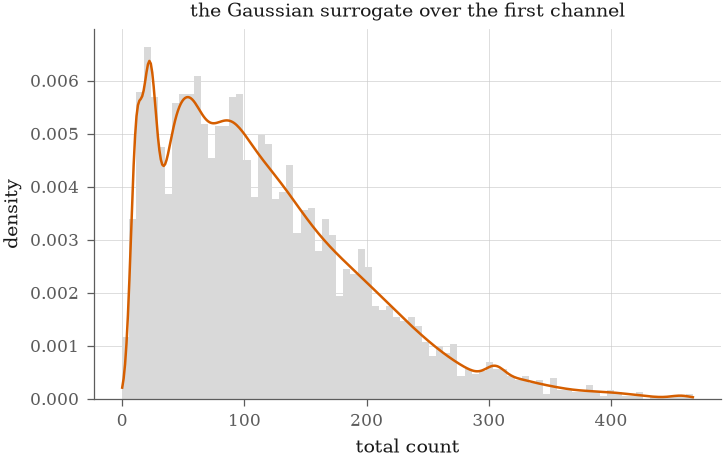

In [8]:
print(table(["gaussian-em"]))
print("the start's own fit ended", trials["gaussian-em"][0].fitted.seeding.diagnostics)

grid = np.linspace(totals.min(), totals.max(), 400)
# One Gaussian fit of the first channel from a k-means++ start, drawn from
# its own generator: the surrogate the start reads its locations off.
control = mixture_seeding.fitted(
    totals, projected.n_components, np.random.default_rng([SEED, 0])
)
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.4, 3.2))
    axis.hist(totals, bins=80, density=True, color="0.85")
    axis.plot(
        grid,
        # The fitted mixture's density on the grid, from the family's own
        # log-density.
        mixture_seeding.density(grid, control.weights.numpy(), control.components),
        color="#D55E00",
        linewidth=1.2,
    )
    axis.set_xlabel("total count")
    axis.set_ylabel("density")
    axis.set_title("the Gaussian surrogate over the first channel", fontsize=9)
    plt.show()

### (e) The four starts of `opt.initialize`

These take an `Objective` and nothing else, so they run on the surrogate the
projection declares: a Gaussian mixture over the first channel, which is an
`Objective` already. `FromObjective` is the objective's own nominated point,
`Perturbed` that point tilted off a symmetry it may be stationary at,
`RandomRestart` four points drawn around it with the best by surrogate value
kept, and `quantile_locations` the evenly spaced quantiles of the data. Each
yields locations, which `search.projection.seed_at_means` realizes at the
observations nearest them. Three read no generator and run once.
`test_a_start_built_from_the_surrogate_s_locations_recovers_the_truth`
(`tests/regression/search/test_projection_seeding.py`) pins that the nominated
point and the quantile placement are one seeding on the `ci` projection; the
last lines check it here.

In [9]:
print(table(["objective", "perturbed", "restart", "quantile"]))


def same_seeding(first: str, second: str) -> bool:
    # Whether two starts' seeded components agree parameter for parameter.
    one = trials[first][0].fitted.seeding.components.named_parameters()
    two = trials[second][0].fitted.seeding.components.named_parameters()
    return all(bool((one[key] == two[key]).all()) for key in one)


print()
print(
    "objective and quantile seed the same components:",
    same_seeding("objective", "quantile"),
)
print(
    "objective and perturbed seed the same components:",
    same_seeding("objective", "perturbed"),
)

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | state bytes |
|---|---|---|---|---|---|---|---|---|
| objective | deterministic | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 0.0 | 4800 |
| perturbed | deterministic | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 0.0 | 4800 |
| restart | 1 trial | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 4.0 | 4800 |
| quantile | deterministic | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 0.0 | 4800 |

objective and quantile seed the same components: True
objective and perturbed seed the same components: True


### (f) The three starts of `sample.initialize`, and the burn-in

`FromChain` runs a short Hamiltonian chain on the surrogate and keeps its last
draw, `FromAnnealing` the best point of a falling temperature, `FromTempering`
the best point at any temperature of a ladder. All three charge two passes a
gradient and are set to spend the same 72 gradients, so what separates them is
where the proposals go. `burn_in_seeding` is what the coupled model's own
annealed start reduces to in projection: a short fit on a subsample. The
diagnostics are the first trial's.

In [10]:
print(table(["burn-in", "hmc", "anneal", "tempering"]))
print()
print("chain diagnostics, seed 0")
for label in ("hmc", "anneal", "tempering"):
    print(f"  {label:10s} {trials[label][0].fitted.seeding.diagnostics}")

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | state bytes |
|---|---|---|---|---|---|---|---|---|
| burn-in | 1 trial | -35375.5 | -35289.1 | -30.1 | 0.048 | 0.580 | 0.6 | 4800 |
| hmc | 1 trial | -35843.9 | -35291.5 | -27.6 | 0.053 | 0.699 | 144.0 | 4800 |
| anneal | 1 trial | -35799.3 | -35291.9 | -27.2 | 0.052 | 0.736 | 144.0 | 4800 |
| tempering | 1 trial | -35808.3 | -35291.0 | -28.1 | 0.048 | 0.810 | 144.0 | 4800 |

chain diagnostics, seed 0
  hmc        acceptance 1.00, mean energy error 3.96e-02
  anneal     acceptance 1.00
  tempering  cold acceptance 1.00, lowest swap 0.00


## Where each start places its components, and where its fit leaves them

Two panels per start, seed 0 for a start that reads a generator: the components the start seeded (left) and the
components the fit reached at the budget (right), each at its negative-binomial
mean and beta-binomial mean, over the observations in grey and the generating
components as crosses. The second figure is the fit's iteration against the
gap below the reference, one line per start at seed 0, read from the curve
each cell's run recorded, and beside it each start's gap at the budget, its
bar the mean and its whisker the range over the trials.

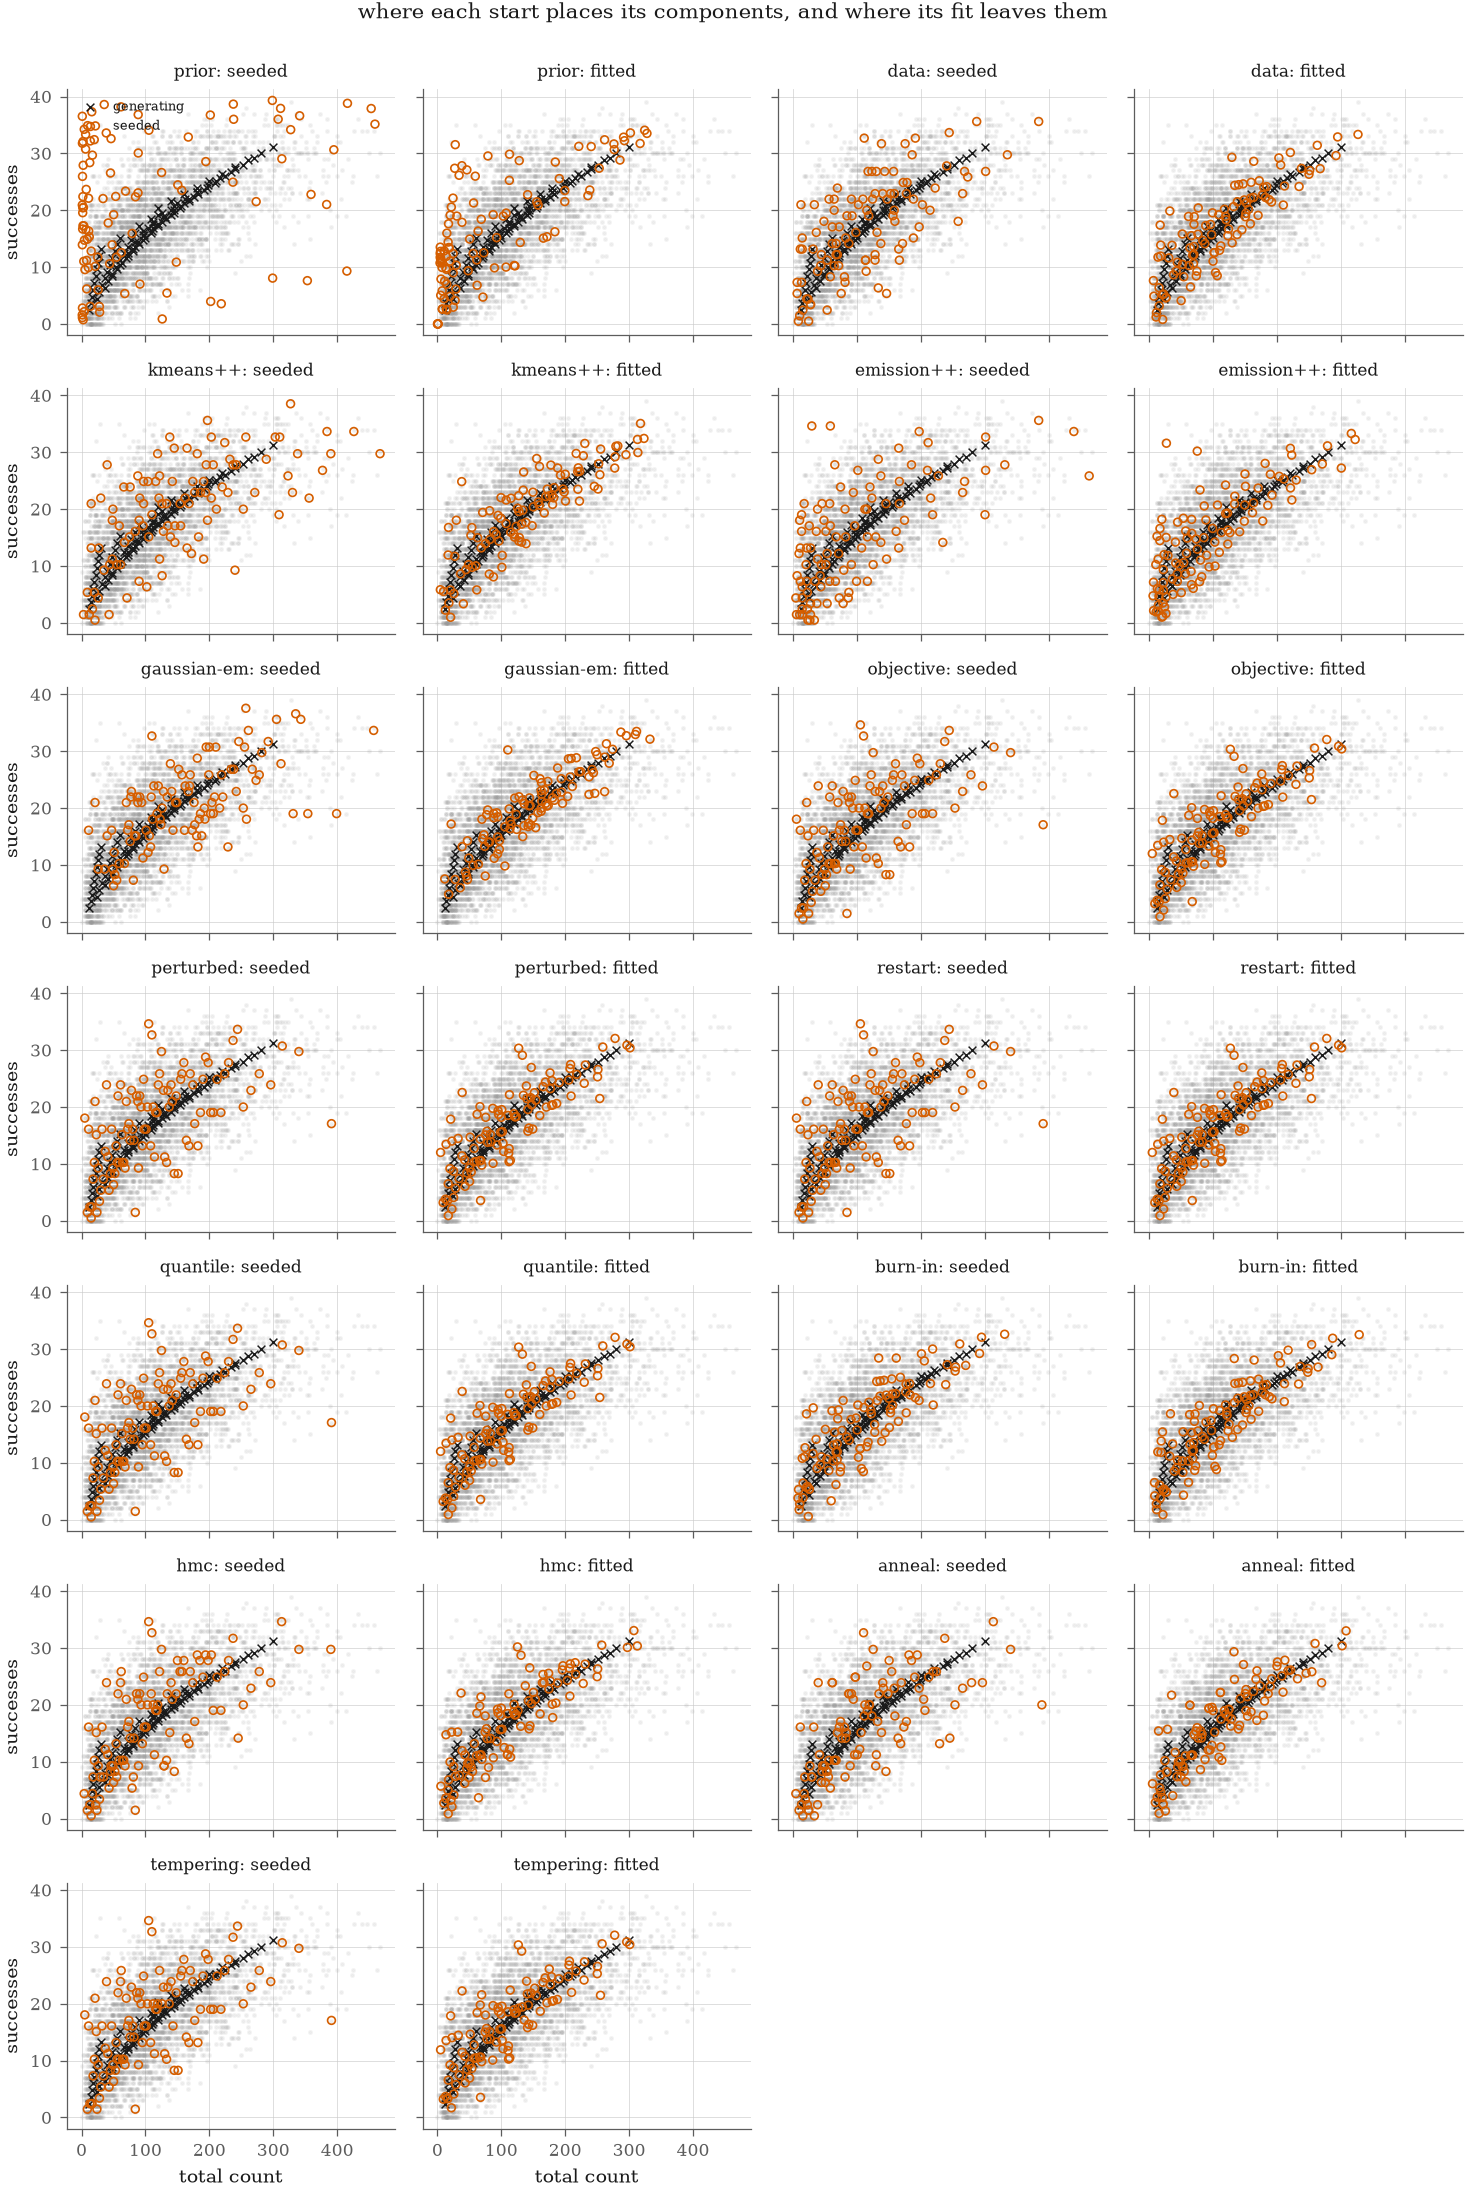

In [11]:
with notebook_style():
    figure, axes = plt.subplots(7, 4, figsize=(10.0, 15.0), sharex=True, sharey=True)
    panels = axes.ravel()
    for index, label in enumerate(ORDER):
        fitted = trials[label][0].fitted
        for side, (family, title) in enumerate(
            ((fitted.seeding.components, "seeded"), (fitted.components, "fitted"))
        ):
            axis = panels[2 * index + side]
            axis.scatter(
                projected.observations[:, 0],
                projected.observations[:, 1],
                s=2,
                alpha=0.10,
                color="0.6",
            )
            axis.scatter(
                truth.total.mean.numpy(),
                truth.successes.mean.numpy(),
                marker="x",
                s=14,
                linewidth=0.7,
                color="0.1",
                label="generating",
            )
            axis.scatter(
                family.total.mean.numpy(),
                family.successes.mean.numpy(),
                marker="o",
                s=14,
                facecolor="none",
                edgecolor="#D55E00",
                linewidth=0.8,
                label=title,
            )
            axis.set_title(f"{label}: {title}", fontsize=8)
    for axis in panels[2 * len(ORDER) :]:
        axis.set_axis_off()
    for axis in axes[-1]:
        axis.set_xlabel("total count")
    for axis in axes[:, 0]:
        axis.set_ylabel("successes")
    panels[0].legend(fontsize=6, loc="upper left")
    figure.suptitle(
        "where each start places its components, and where its fit leaves them",
        fontsize=10,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.98))
    plt.show()

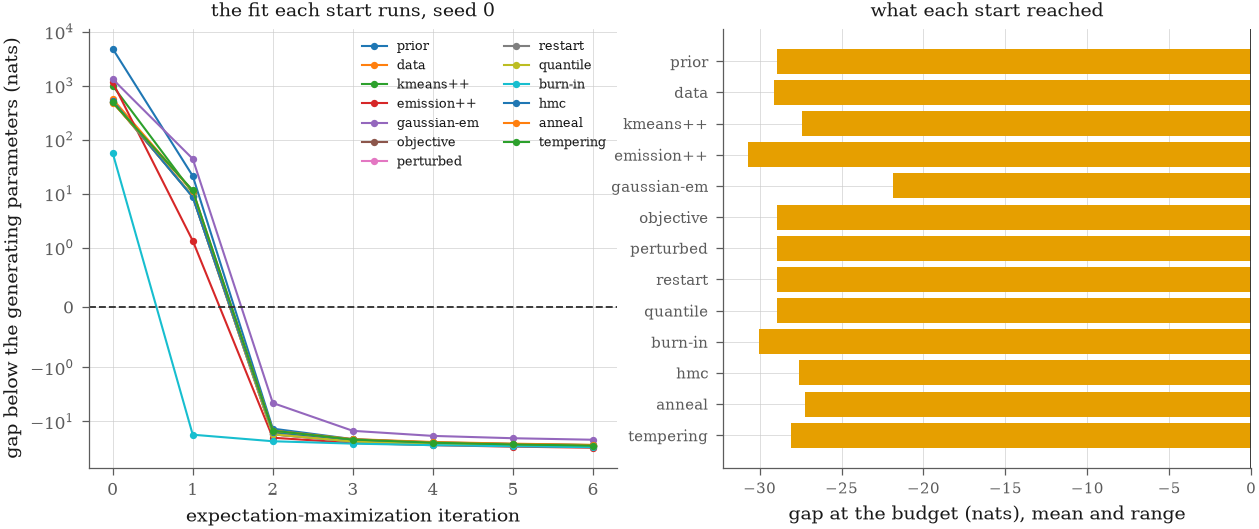

the dashed line and the zero of the bars are the generating parameters; a curve below it or a bar left of it passed them


In [12]:
#: Where the symmetric-log axis turns linear: one nat either side of the
#: reference, so a fit that passes it keeps its sign on the plot.
LINEAR_WITHIN = 1.0

palette = discrete_palette(1)
with notebook_style():
    figure, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
    for label in ORDER:
        recorded = np.asarray(trials[label][0].curve)
        axes[0].plot(
            range(len(recorded)),
            REFERENCE - recorded,
            marker="o",
            markersize=2.5,
            linewidth=1.0,
            label=label,
        )
    axes[0].set_yscale("symlog", linthresh=LINEAR_WITHIN)
    axes[0].axhline(0.0, color="0.2", linewidth=0.9, linestyle="--")
    axes[0].set_xlabel("expectation-maximization iteration")
    axes[0].set_ylabel("gap below the generating parameters (nats)")
    axes[0].set_title("the fit each start runs, seed 0", fontsize=9)
    axes[0].legend(fontsize=6, ncol=2)

    gaps = [
        np.asarray([REFERENCE - run.fitted.log_likelihood for run in trials[label]])
        for label in ORDER
    ]
    means = np.asarray([g.mean() for g in gaps])
    whiskers = np.asarray(
        [[g.mean() - g.min() for g in gaps], [g.max() - g.mean() for g in gaps]]
    )
    axes[1].barh(ORDER, means, xerr=whiskers, color=palette[0], ecolor="0.2")
    axes[1].axvline(0.0, color="0.2", linewidth=0.9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("gap at the budget (nats), mean and range")
    axes[1].set_title("what each start reached", fontsize=9)
    axes[1].tick_params(labelsize=7)
    plt.show()
print(
    "the dashed line and the zero of the bars are the generating parameters; "
    "a curve below it or a bar left of it passed them"
)

## The comparison at an equal budget, in seconds

Every start spent the same six passes; this section states what that cost in
wall clock. The table is the rows above with the seconds column: the seeding
and the fit together, per cell, its mean and range over the trials. Beneath it
are the two `opt.budget.compare` tables in `Cost.SECONDS`: hits of the
reference, the gap of the best trial, and the whole seconds the slowest trial
spent against the ceiling. The **passes** column stays beside the seconds,
since experiment 009 counted passes and a pass is the unit that transfers
between hosts; a second is quoted with the host and the load it was read
under, printed first. The cell is tagged `wall-clock`, so the notebook checker
runs it and does not compare its text (`docs/nb/README.md`).

In [13]:
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{load_before[0]:.2f} before the trials and {load_after[0]:.2f} after; "
    f"the trials took {elapsed:.0f} s"
)
print()
print(table(ORDER, seconds=True))
for group, comparison in comparisons.items():
    print()
    print(f"{group} starts, {len(GROUPS[group][1])} seed(s):")
    print(comparison.table())

host: 4 cores, 4 workers; 1-minute load 1.46 before the trials and 2.86 after; the trials took 117 s

| start | trials | seeded value | reached value | gap (nats) | recovery | mean relative error | passes | seconds | state bytes |
|---|---|---|---|---|---|---|---|---|---|
| prior | 1 trial | -40145.0 | -35290.2 | -28.9 | 0.025 | 1.000 | 0.0 | 23.0 | 4800 |
| data | 1 trial | -35882.3 | -35290.0 | -29.1 | 0.043 | 0.695 | 0.0 | 27.0 | 4800 |
| kmeans++ | 1 trial | -36315.0 | -35291.7 | -27.4 | 0.039 | 1.804 | 1.0 | 26.1 | 4800 |
| emission++ | 1 trial | -36468.2 | -35288.4 | -30.7 | 0.034 | 0.897 | 1.0 | 31.6 | 4800 |
| gaussian-em | 1 trial | -36636.1 | -35297.2 | -21.9 | 0.025 | 4.353 | 500.0 | 34.3 | 4800 |
| objective | deterministic | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 0.0 | 26.7 | 4800 |
| perturbed | deterministic | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 0.0 | 26.9 | 4800 |
| restart | 1 trial | -35824.8 | -35290.2 | -28.9 | 0.049 | 0.809 | 4.0 | 27.0 | 4800 |
| 

## Read beside experiment 009

Experiment 009 ran nine of these starts on the key model in projection --- 100
components, 4,000 observations, 40 a component, the size of this projection ---
over six paired instances. Its two orderings were opposite: `emission++` led the
likelihood at 0.4 nats below the best, while on recovery `data` and `tempering`
beat the prior draw 6 of 6 and lost to it on the likelihood. No default moved
(#559).

**Both orderings appear here, and one trial separates neither.** On the
likelihood `emission++` is first, 30.7 nats past the reference; on recovery it
is ninth of thirteen at 0.034, and `hmc` at 0.053 and `anneal` at 0.052 lead,
against the 0.054 the generating parameters reach and a chance of 0.01. Rows
that neighbour each other differ by under 1.5 nats on the gap and 0.005 on
recovery, and at one trial there is no range to read that difference against,
so neither ordering is a finding of this notebook and #559 keeps the defaults.

**Every start passes the reference, by 21.9 to 30.7 nats.** At 40 observations
a component, six passes fit the draw closer than the generating parameters do;
a gap below zero is a fit that passed the truth's own value, not one that found
the truth. The recovery column is beside the gap for that reason, and every hit
in the `compare` tables is this same passing.

**What carries over is the chains' diagnostics and the cost column.** Every
chain accepts every proposal and the tempering ladder's lowest swap acceptance
is 0.00, as at the key model: on a surrogate this sharp they are optimizers,
not samplers. They charge 144 passes against the fit's 6, and buy `hmc`'s 0.053
recovery over the free `data` start's 0.043. In seconds the chain-based starts
cost about what `data` does (the last table): a surrogate pass is a Gaussian
density over one channel, where a fit pass carries the beta-binomial M step, so
a pass is not one unit of time across the two and the table carries both.

**Three of the four `opt.initialize` starts are one seeding**, as section (e)
prints, and at seed 0 `restart` keeps the nominated point as well: its row is
`objective`'s but for the 4 passes it charged.

## Further work

- The seedings are scored in projection and not on the coupled fit: at this
  instance the coupled fit's M step is the cost, and no seeding is yet read
  through the full model: issue #555.
- Spectral seeding by moment inversion, the sixth candidate of #541, is not
  among the starts because no implementation exists: issue #554.
- Nothing here moves a default; the orderings are read beside experiment 009's
  and not tested against them: issue #559.
- The coupled model's own start, `seed_emissions`, seeds the class labels'
  model over categorical families and is not run on the count-pair instance:
  issue #887.
- The count-pair coupled instance has no notebook of its own, and this one is
  the seventh of the eighteen catalogue rows: issue #682.